In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


# Imports

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer,KNNImputer
from sklearn.metrics import accuracy_score

# ask basic questions 

In [4]:
df = pd.read_csv("/kaggle/input/titanic/train.csv")
test = pd.read_csv('/kaggle/input/titanic/test.csv')
gender = pd.read_csv('/kaggle/input/titanic/gender_submission.csv')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.sample()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
593,594,0,3,"Bourke, Miss. Mary",female,NaN,0,2,364848,7.75,NaN,Q


In [7]:
df.isnull().mean()*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [8]:
df.duplicated().sum()

0

In [9]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# feature selection and EDA

In [10]:
df['family'] = df['SibSp']+df['Parch']+1

In [11]:
df.drop(columns = ["Name","Ticket","Cabin",'SibSp','Parch'],inplace=True)

In [12]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked,family
0,1,0,3,male,22.0,7.2500,S,2
1,2,1,1,female,38.0,71.2833,C,2
2,3,1,3,female,26.0,7.9250,S,1
3,4,1,1,female,35.0,53.1000,S,2
4,5,0,3,male,35.0,8.0500,S,1


In [13]:
numeric_col = pd.DataFrame(df.select_dtypes(include = ['int64','float64']))
numeric_col = [c for c in numeric_col if c !='Survived']
cat_col = df.select_dtypes(include = ['object','category'])

In [14]:
numeric_col

['PassengerId', 'Pclass', 'Age', 'Fare', 'family']

In [15]:
cat_col

,Sex,Embarked
0,male,S
1,female,C
2,female,S
3,female,S
4,male,S
...,...,...
886,male,S
887,female,S
888,female,S
889,male,C


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


<Figure size 640x480 with 0 Axes>

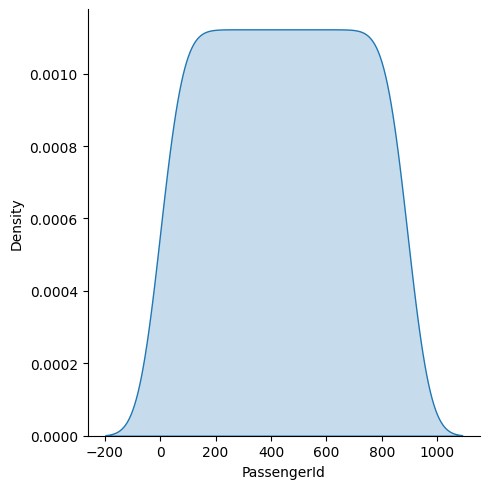

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


<Figure size 640x480 with 0 Axes>

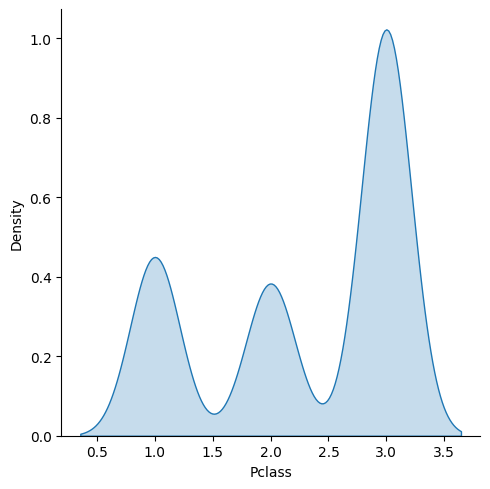

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


<Figure size 640x480 with 0 Axes>

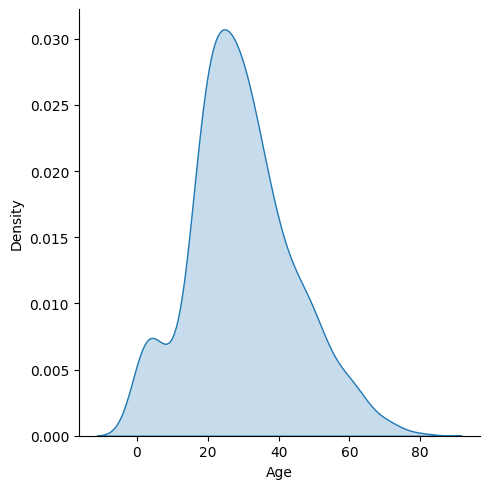

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


<Figure size 640x480 with 0 Axes>

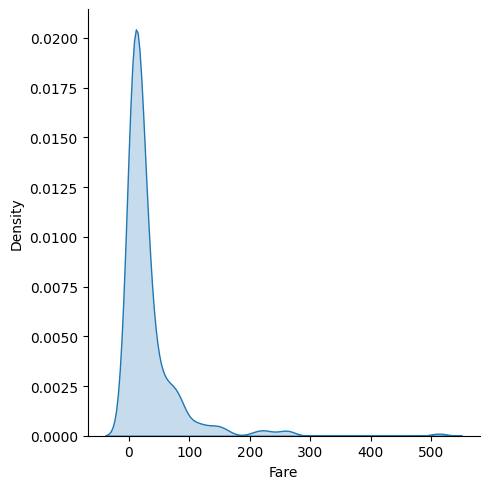

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


<Figure size 640x480 with 0 Axes>

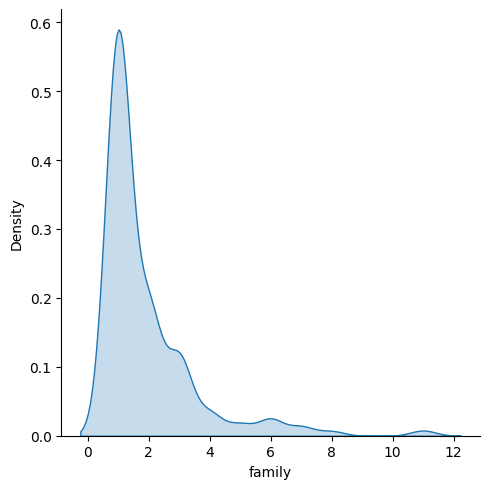

In [16]:
for col in numeric_col:
    plt.figure()
    sns.displot(x=df[col],kind='kde',fill =True)
    plt.show() 

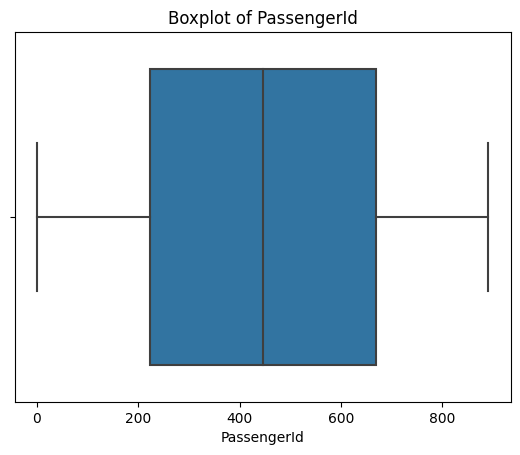

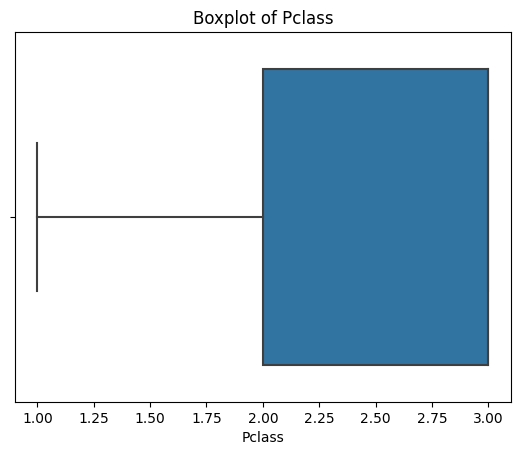

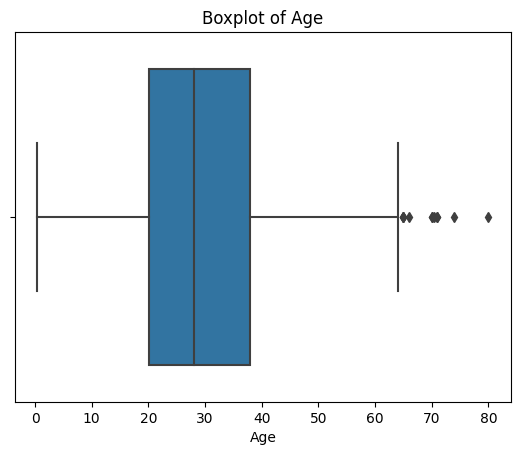

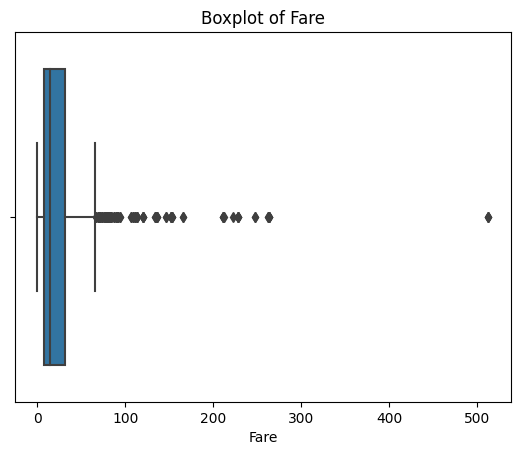

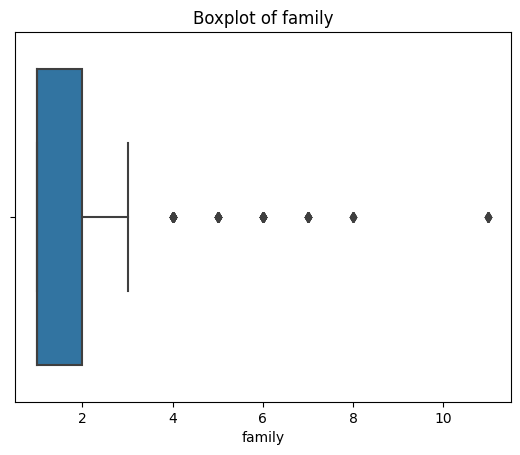

In [17]:
for col in numeric_col:
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


In [18]:
df[numeric_col].corr()

,PassengerId,Pclass,Age,Fare,family
PassengerId,1.000000,-0.035144,0.036847,0.012658,-0.040143
Pclass,-0.035144,1.000000,-0.369226,-0.549500,0.065997
Age,0.036847,-0.369226,1.000000,0.096067,-0.301914
Fare,0.012658,-0.549500,0.096067,1.000000,0.217138
family,-0.040143,0.065997,-0.301914,0.217138,1.000000


# outliers

In [19]:
# for normal distribution
Highest = df['Age'].mean()+ 3*df['Age'].std()
Lowest = df['Age'].mean()- 3*df['Age'].std()

In [20]:
df['Age'] = np.where(
    df['Age']> Highest , Highest ,
    np.where(
        df['Age']< Lowest , Lowest , df['Age']
    )
)

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)


In [21]:
# skewed distribution
percentile25f = df['Fare'].quantile(0.25)
percentile75f = df['Fare'].quantile(0.75)
percentile25 = df['family'].quantile(0.25)
percentile75 = df['family'].quantile(0.75)

In [22]:
iqr = percentile75 - percentile25
iqrc = percentile75f - percentile25f

In [23]:
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
upper_limitc = percentile75f + 1.5 * iqrc
lower_limitc = percentile25f - 1.5 * iqrc


In [24]:
df['Fare'] = np.where(
    df['Fare']> upper_limitc , upper_limitc ,
    np.where(
        df['Fare']< lower_limitc , lower_limitc , df['Fare']
    )
)

In [25]:
df['family'] = np.where(
    df['family']> upper_limit , upper_limit ,
    np.where(
        df['family']< lower_limit , lower_limit , df['family']
    )
)

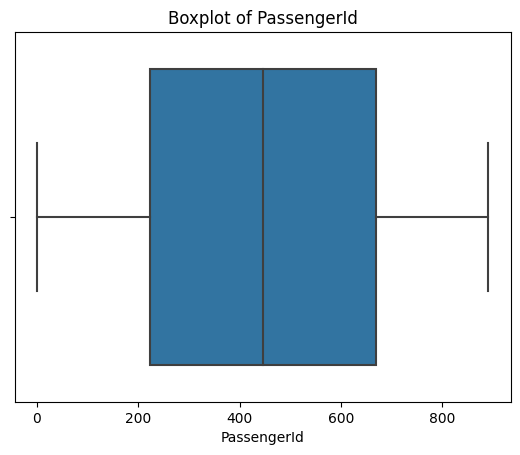

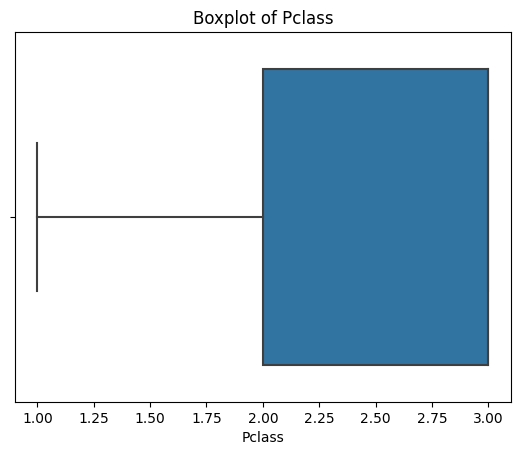

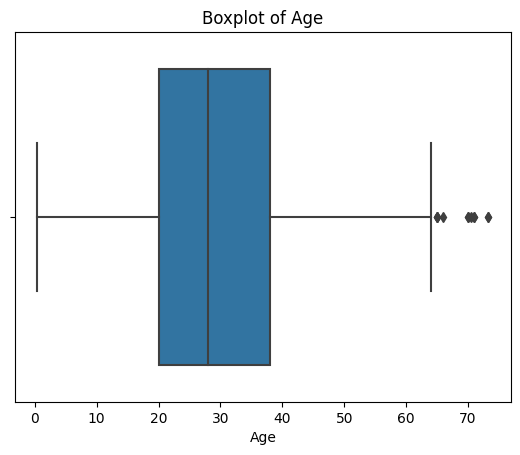

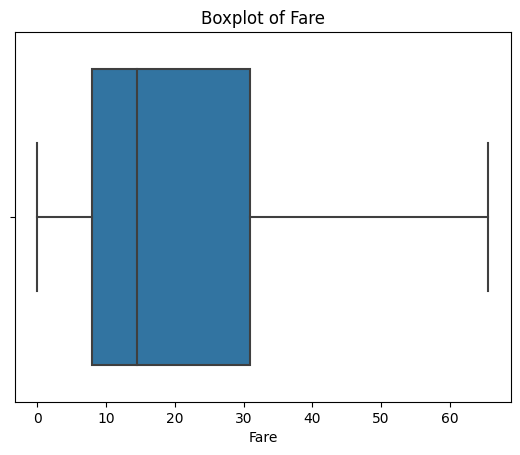

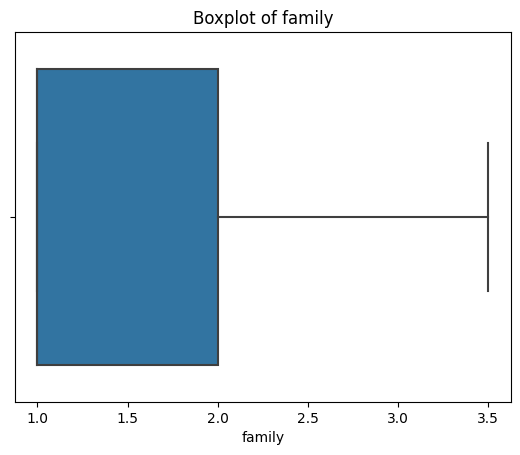

In [26]:
for col in numeric_col:
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


# model

In [27]:
x_train,x_test,y_train,y_test = train_test_split(df.drop(columns=["Survived"]),
                                                 df["Survived"],test_size=0.2,random_state=42)

In [28]:
x_train.head()

,PassengerId,Pclass,Sex,Age,Fare,Embarked,family
331,332,1,male,45.5,28.5000,S,1.0
733,734,2,male,23.0,13.0000,S,1.0
382,383,3,male,32.0,7.9250,S,1.0
704,705,3,male,26.0,7.8542,S,2.0
813,814,3,female,6.0,31.2750,S,3.5


In [29]:
numerical_features = ['PassengerId', 'Pclass','Age','Fare','family']
categorical_features = ['Sex','Embarked']

In [30]:
numerical_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=2,weights = 'distance'))
])



In [31]:
categorical_transformer = Pipeline(steps=[
    ('imputer_emBARKED',SimpleImputer(strategy='most_frequent')),
    ('ohe',OneHotEncoder(handle_unknown='ignore'))
     ])    

In [32]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' 
)

In [33]:

trf5 = RandomForestClassifier(n_estimators=100, random_state=42)

In [34]:
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', trf5)
])

model_pipeline.fit(x_train, y_train)
predictions = model_pipeline.predict(x_test)

In [35]:

accuracy_score(y_test,predictions)

0.8268156424581006

# creating submission

In [36]:
test['family'] = test['SibSp'] + test['Parch'] + 1


In [37]:
test.drop(columns=["Name", "Ticket", "Cabin", "SibSp", "Parch"], inplace=True)


In [38]:
test_predictions = model_pipeline.predict(test)


In [39]:
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': test_predictions.astype(int)
})
submission.to_csv('submission.csv', index=False)
